# HW4 — Sequence Modeling: Financial Forecasting
**CS515 Deep Learning | Sabanci University**

Bu notebook:
1. Repoyu çeker ve uv ile eksik bağımlılıkları kurar
2. Part b (exact return), Part c (rolling return), Part d (turning point) deneylerini GPU üzerinde çalıştırır
3. Sonuçları gösterir ve indirmeye hazırlar

> **Önemli:** Runtime → Change runtime type → **T4 GPU** seçili olmalı.

## 0. GPU Kontrolü

In [1]:
import torch

print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: GPU yok — Runtime menüsünden T4 GPU seç!')

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


## 1. Repo Kurulumu

In [2]:
import os

REPO_URL = 'https://github.com/caltinuzengi/cs515-deep-learning.git'
REPO_DIR = 'cs515-deep-learning'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    print('Repo is already exist, being updated...')
    !git -C {REPO_DIR} pull

os.chdir(REPO_DIR)
print(f'Directory: {os.getcwd()}')

Cloning into 'cs515-deep-learning'...
remote: Enumerating objects: 427, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 427 (delta 22), reused 32 (delta 16), pack-reused 378 (from 3)
Receiving objects: 100% (427/427), 507.91 MiB | 19.58 MiB/s, done.
Resolving deltas: 100% (91/91), done.
Updating files: 100% (270/270), done.
Directory: /content/cs515-deep-learning


## 2. Bağımlılık Kurulumu (uv)

Colab'ın CUDA-enabled torch'u korunur; sadece eksik paketler eklenir.

In [ ]:
# Install uv (with PyPI)
!pip install uv -q

# Add missing packages to the system Python (does not change Colab's torch/CUDA)
!uv pip install --system yfinance scikit-learn ptflops -q

# Check versions of the installed packages
import yfinance, sklearn
print(f'yfinance   : {yfinance.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'torch      : {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 80.6 MB/s eta 0:00:00:00:0100:01
yfinance   : 0.2.66
scikit-learn: 1.6.1
torch      : 2.11.0+cu128


## 3. Veri İndirme ve Doğrulama

In [4]:
!python hw4/data_pipeline.py

=== Downloading data ===
  AAPL: 1508 rows → data/stocks/raw/AAPL.csv
  MSFT: 1508 rows → data/stocks/raw/MSFT.csv
  GOOGL: 1508 rows → data/stocks/raw/GOOGL.csv

=== ReturnDataset (exact) ===
  train: 3399 samples
  val  : 318 samples
  test : 735 samples

=== ReturnDataset (rolling) ===
  train: 3399 samples
  val  : 318 samples
  test : 735 samples

=== TurningPointDataset ===
  train: 3399 samples  |  class 1: 113 (3.3%)  class 0: 3286 (96.7%)
  val  : 318 samples  |  class 1: 7 (2.2%)  class 0: 311 (97.8%)
  test : 735 samples  |  class 1: 32 (4.4%)  class 0: 703 (95.6%)

=== Batch shapes ===
  X:         (64, 20, 4)
  y_exact:   (64, 5)
  y_rolling: (64, 5)
  y_binary:  (64, 1)


## 4. Part b — Exact Return Forecasting (StockLSTM & StockGRU)

In [5]:
!python hw4/experiment_b.py --retrain

device: cuda
loading data...

[StockLSTM] training...
Epoch   1/100 * | train=0.001622 | val=0.000700 | best=1
Epoch   2/100 * | train=0.001165 | val=0.000688 | best=2
Epoch   3/100 * | train=0.001120 | val=0.000666 | best=3
Epoch   4/100 * | train=0.001111 | val=0.000630 | best=4
Epoch   5/100   | train=0.001087 | val=0.000644 | best=4
Epoch   6/100   | train=0.001079 | val=0.000649 | best=4
Epoch   7/100   | train=0.001071 | val=0.000666 | best=4
Epoch   8/100   | train=0.001069 | val=0.000703 | best=4
Epoch   9/100 * | train=0.001072 | val=0.000624 | best=9
Epoch  10/100   | train=0.001064 | val=0.000633 | best=9
Epoch  11/100   | train=0.001055 | val=0.000687 | best=9
Epoch  12/100   | train=0.001053 | val=0.000684 | best=9
Epoch  13/100   | train=0.001054 | val=0.000648 | best=9
Epoch  14/100   | train=0.001049 | val=0.000681 | best=9
Epoch  15/100   | train=0.001050 | val=0.000665 | best=9
Epoch  16/100   | train=0.001047 | val=0.000662 | best=9
Epoch  17/100   | train=0.001044 |

## 5. Part c — Rolling Average Return Forecasting

In [6]:
!python hw4/experiment_c.py --retrain

device: cuda
loading data...

[StockLSTM] training...
Epoch   1/100 * | train=0.001028 | val=0.000298 | best=1
Epoch   2/100   | train=0.000566 | val=0.000316 | best=1
Epoch   3/100 * | train=0.000527 | val=0.000281 | best=3
Epoch   4/100 * | train=0.000507 | val=0.000279 | best=4
Epoch   5/100   | train=0.000490 | val=0.000283 | best=4
Epoch   6/100   | train=0.000488 | val=0.000288 | best=4
Epoch   7/100   | train=0.000478 | val=0.000289 | best=4
Epoch   8/100   | train=0.000473 | val=0.000318 | best=4
Epoch   9/100 * | train=0.000476 | val=0.000272 | best=9
Epoch  10/100   | train=0.000467 | val=0.000274 | best=9
Epoch  11/100   | train=0.000462 | val=0.000296 | best=9
Epoch  12/100   | train=0.000461 | val=0.000305 | best=9
Epoch  13/100   | train=0.000460 | val=0.000296 | best=9
Epoch  14/100   | train=0.000456 | val=0.000290 | best=9
Epoch  15/100   | train=0.000457 | val=0.000295 | best=9
Epoch  16/100   | train=0.000455 | val=0.000286 | best=9
Epoch  17/100   | train=0.000451 |

## 6. Part d — Turning Point Detection (BiStockLSTM & BiStockGRU)

In [7]:
# Baseline: gamma=1.10 (10% gain threshold), loss-based early stopping, patience=10
!python hw4/experiment_d.py --retrain

device: cuda
run tag: g110_loss  (gamma=1.1, patience=10, val_metric=loss)
loading data...
class balance — pos: 113 (3.3%)  neg: 3286 (96.7%)  pos_weight: 29.08

[BiStockLSTM] training (gamma=1.1, patience=10, val_metric=loss)...
Epoch   1/100 * | train=1.296939 | val=1.228114 | best=1
Epoch   2/100 * | train=1.247366 | val=1.130044 | best=2
Epoch   3/100   | train=1.238452 | val=1.229615 | best=2
Epoch   4/100   | train=1.242244 | val=1.245304 | best=2
Epoch   5/100   | train=1.247523 | val=1.243055 | best=2
Epoch   6/100   | train=1.239072 | val=1.164673 | best=2
Epoch   7/100   | train=1.228446 | val=1.165398 | best=2
Epoch   8/100   | train=1.225623 | val=1.241009 | best=2
Epoch   9/100   | train=1.233669 | val=1.195858 | best=2
Epoch  10/100   | train=1.235030 | val=1.181323 | best=2
Epoch  11/100   | train=1.232706 | val=1.226278 | best=2
Epoch  12/100   | train=1.233617 | val=1.252356 | best=2
Early stopping at epoch 12 [val loss] (best=2)
[BiStockLSTM] loss curve → results/hw4/

### Part d — Additional Experiments: GAMMA & Early Stopping Ablation

The baseline (γ=1.10, loss-based stopping) yields a degenerate all-class-0 classifier.
Three ablations investigate two remedies: lowering the buy threshold to increase positive sample count, and switching to F1-based early stopping so the model is checkpointed on the metric that actually matters.

| Run tag | γ | patience | val_metric | Hypothesis |
|---------|---|----------|------------|------------|
| `g105_loss` | 1.05 | 10 | loss | 5% threshold → ~6% positives → richer gradient signal |
| `g110_f1`   | 1.10 | 5  | f1  | F1-based stopping avoids premature class-0 collapse |
| `g105_f1`   | 1.05 | 5  | f1  | Lower threshold + F1 stopping combined |

In [8]:
# Experiment 1: gamma=1.05 (5% gain threshold) — more positive training samples
!python hw4/experiment_d.py --retrain --gamma 1.05

device: cuda
run tag: g105_loss  (gamma=1.05, patience=10, val_metric=loss)
Overriding GAMMA: 1.1 → 1.05
loading data...
class balance — pos: 717 (21.1%)  neg: 2682 (78.9%)  pos_weight: 3.74

[BiStockLSTM] training (gamma=1.05, patience=10, val_metric=loss)...
Epoch   1/100 * | train=1.045595 | val=0.851228 | best=1
Epoch   2/100   | train=1.034824 | val=0.889526 | best=1
Epoch   3/100   | train=1.035008 | val=0.918076 | best=1
Epoch   4/100   | train=1.028142 | val=0.865867 | best=1
Epoch   5/100   | train=1.025351 | val=0.929718 | best=1
Epoch   6/100   | train=1.023670 | val=0.886567 | best=1
Epoch   7/100   | train=1.021766 | val=0.904245 | best=1
Epoch   8/100   | train=1.018688 | val=0.954069 | best=1
Epoch   9/100   | train=1.020397 | val=0.888729 | best=1
Epoch  10/100   | train=1.013841 | val=0.917328 | best=1
Epoch  11/100   | train=1.006928 | val=0.911501 | best=1
Early stopping at epoch 11 [val loss] (best=1)
[BiStockLSTM] loss curve → results/hw4/plots/part_d_g105_loss_BiS

In [9]:
# Experiment 2: gamma=1.10 + F1-based early stopping + patience=5
!python hw4/experiment_d.py --retrain --patience 5 --val-metric f1

device: cuda
run tag: g110_f1  (gamma=1.1, patience=5, val_metric=f1)
loading data...
class balance — pos: 113 (3.3%)  neg: 3286 (96.7%)  pos_weight: 29.08

[BiStockLSTM] training (gamma=1.1, patience=5, val_metric=f1)...
Early stopping criterion: val F1 (higher is better)
Epoch   1/100 * | train=1.296939 | val=1.228114 | val_f1=0.0000 | best=1
Epoch   2/100   | train=1.236124 | val=1.252285 | val_f1=0.0000 | best=1
Epoch   3/100   | train=1.247098 | val=1.151071 | val_f1=0.0000 | best=1
Epoch   4/100   | train=1.232254 | val=1.224201 | val_f1=0.0000 | best=1
Epoch   5/100   | train=1.236324 | val=1.176961 | val_f1=0.0000 | best=1
Epoch   6/100   | train=1.241095 | val=1.149792 | val_f1=0.0000 | best=1
Early stopping at epoch 6 [val F1] (best=1)
[BiStockLSTM] loss curve → results/hw4/plots/part_d_g110_f1_BiStockLSTM_loss.png

  [BiStockLSTM] Confusion Matrix:
               Pred 0   Pred 1
  Actual 0       703        0
  Actual 1        32        0
[BiStockLSTM] metrics → results/hw4/m

In [10]:
# Experiment 3: gamma=1.05 + F1-based early stopping + patience=5 (combined)
!python hw4/experiment_d.py --retrain --gamma 1.05 --patience 5 --val-metric f1

device: cuda
run tag: g105_f1  (gamma=1.05, patience=5, val_metric=f1)
Overriding GAMMA: 1.1 → 1.05
loading data...
class balance — pos: 717 (21.1%)  neg: 2682 (78.9%)  pos_weight: 3.74

[BiStockLSTM] training (gamma=1.05, patience=5, val_metric=f1)...
Early stopping criterion: val F1 (higher is better)
Epoch   1/100 * | train=1.045595 | val=0.851228 | val_f1=0.0000 | best=1
Epoch   2/100   | train=1.031960 | val=0.864533 | val_f1=0.0000 | best=1
Epoch   3/100   | train=1.033877 | val=0.875959 | val_f1=0.0000 | best=1
Epoch   4/100   | train=1.029020 | val=0.932383 | val_f1=0.0000 | best=1
Epoch   5/100   | train=1.026730 | val=0.913031 | val_f1=0.0000 | best=1
Epoch   6/100   | train=1.021563 | val=0.899516 | val_f1=0.0000 | best=1
Early stopping at epoch 6 [val F1] (best=1)
[BiStockLSTM] loss curve → results/hw4/plots/part_d_g105_f1_BiStockLSTM_loss.png

  [BiStockLSTM] Confusion Matrix:
               Pred 0   Pred 1
  Actual 0       588        0
  Actual 1       147        0
[BiSto

In [11]:
# All Part d runs accumulated — compare gamma and early-stopping variants side by side
!python hw4/experiment_d.py

device: cuda
run tag: g110_loss  (gamma=1.1, patience=10, val_metric=loss)
loading data...
class balance — pos: 113 (3.3%)  neg: 3286 (96.7%)  pos_weight: 29.08

[BiStockLSTM] checkpoint found — skipping training

  [BiStockLSTM] Confusion Matrix:
               Pred 0   Pred 1
  Actual 0       703        0
  Actual 1        32        0
[BiStockLSTM] metrics → results/hw4/metrics/part_d_g110_loss_BiStockLSTM.json

[BiStockGRU] checkpoint found — skipping training

  [BiStockGRU] Confusion Matrix:
               Pred 0   Pred 1
  Actual 0       703        0
  Actual 1        32        0
[BiStockGRU] metrics → results/hw4/metrics/part_d_g110_loss_BiStockGRU.json

Part d — Binary Classification Results
Model             Tag             Accuracy  Precision  Recall      F1
-----------------------------------------------------------------------
BiStockLSTM       g110_loss         0.9565     0.0000  0.0000  0.0000
BiStockGRU        g110_loss         0.9565     0.0000  0.0000  0.0000

=== All 

## 7. Sonuçlar — Metrikler

In [12]:
import json, glob

for path in sorted(glob.glob('results/hw4/metrics/*.json')):
    with open(path) as f:
        data = json.load(f)
    print(f"\n{'='*55}")
    print(f"  {os.path.basename(path)}")
    print(f"{'='*55}")
    print(f"  model      : {data.get('model', '?')}")
    print(f"  best_epoch : {data.get('best_epoch', '?')}")
    if 'mean_mse' in data:
        print(f"  mean_mse   : {data['mean_mse']:.6f}")
        mse_str = ', '.join(f'd{i+1}={v:.4f}' for i, v in enumerate(data['per_horizon_mse']))
        print(f"  per horizon: {mse_str}")
        if data.get('stability_std') is not None:
            print(f"  stab_std   : {data['stability_std']:.6f}")
    if 'f1' in data:
        if data.get('run_tag'):
            print(f"  run_tag    : {data['run_tag']}  "
                  f"(gamma={data.get('gamma')}  patience={data.get('patience')}  "
                  f"val_metric={data.get('val_metric')})")
        print(f"  accuracy   : {data['accuracy']:.4f}")
        print(f"  precision  : {data['precision']:.4f}")
        print(f"  recall     : {data['recall']:.4f}")
        print(f"  f1         : {data['f1']:.4f}")
        cm = data['confusion_matrix']
        print(f"  conf_mat   : TN={cm[0][0]}  FP={cm[0][1]}  FN={cm[1][0]}  TP={cm[1][1]}")


  part_b_StockGRU.json
  model      : StockGRU
  best_epoch : 7
  mean_mse   : 0.001114
  per horizon: d1=0.0004, d2=0.0007, d3=0.0011, d4=0.0015, d5=0.0018
  stab_std   : 0.000343

  part_b_StockLSTM.json
  model      : StockLSTM
  best_epoch : 9
  mean_mse   : 0.001119
  per horizon: d1=0.0004, d2=0.0007, d3=0.0012, d4=0.0015, d5=0.0019
  stab_std   : 0.000127

  part_c_StockGRU.json
  model      : StockGRU
  best_epoch : 14
  mean_mse   : 0.000463
  per horizon: d1=0.0001, d2=0.0001, d3=0.0003, d4=0.0007, d5=0.0011
  stab_std   : 0.000025

  part_c_StockLSTM.json
  model      : StockLSTM
  best_epoch : 9
  mean_mse   : 0.000477
  per horizon: d1=0.0001, d2=0.0001, d3=0.0003, d4=0.0007, d5=0.0011
  stab_std   : 0.000126

  part_d_g105_f1_BiStockGRU.json
  model      : BiStockGRU
  best_epoch : 1
  run_tag    : g105_f1  (gamma=1.05  patience=5  val_metric=f1)
  accuracy   : 0.8000
  precision  : 0.0000
  recall     : 0.0000
  f1         : 0.0000
  conf_mat   : TN=588  FP=0  FN=147  T

## 8. Sonuçlar — Loss Grafikleri

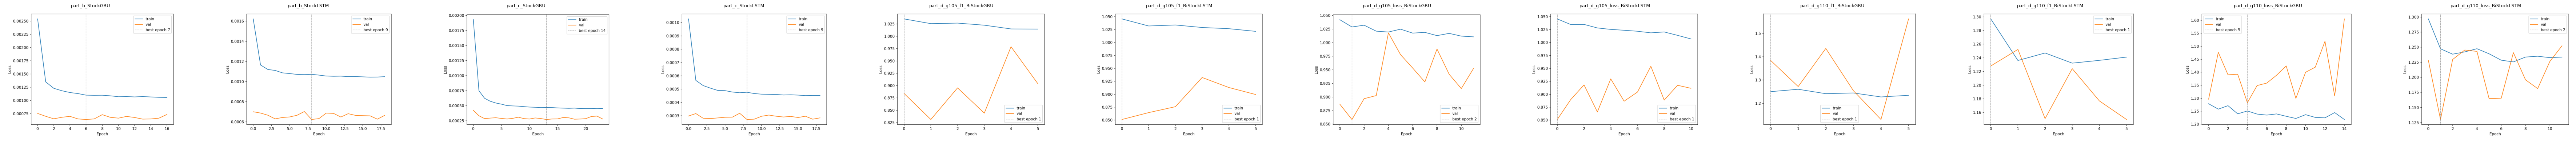

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plots = sorted(glob.glob('results/hw4/plots/*.png'))
if not plots:
    print('Henüz plot yok.')
else:
    fig, axes = plt.subplots(1, len(plots), figsize=(6 * len(plots), 4))
    if len(plots) == 1:
        axes = [axes]
    for ax, path in zip(axes, plots):
        ax.imshow(mpimg.imread(path))
        ax.set_title(os.path.basename(path).replace('_loss.png', ''), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 9. Download Results

All files under the `results/hw4/` will be installed.  
Checkpoints are not included since they are big.

In [ ]:
import shutil
from google.colab import files

# Only metrics and plots — without checkpoints
tmp_dir = '/tmp/hw4_results'
os.makedirs(tmp_dir, exist_ok=True)
for sub in ('metrics', 'plots'):
    shutil.copytree(f'results/hw4/{sub}', f'{tmp_dir}/{sub}', dirs_exist_ok=True)

zip_path = '/tmp/hw4_results'
shutil.make_archive(zip_path, 'zip', tmp_dir)
print('hw4_results.zip ready, downloading...')
files.download(zip_path + '.zip')

hw4_results.zip hazır, indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>